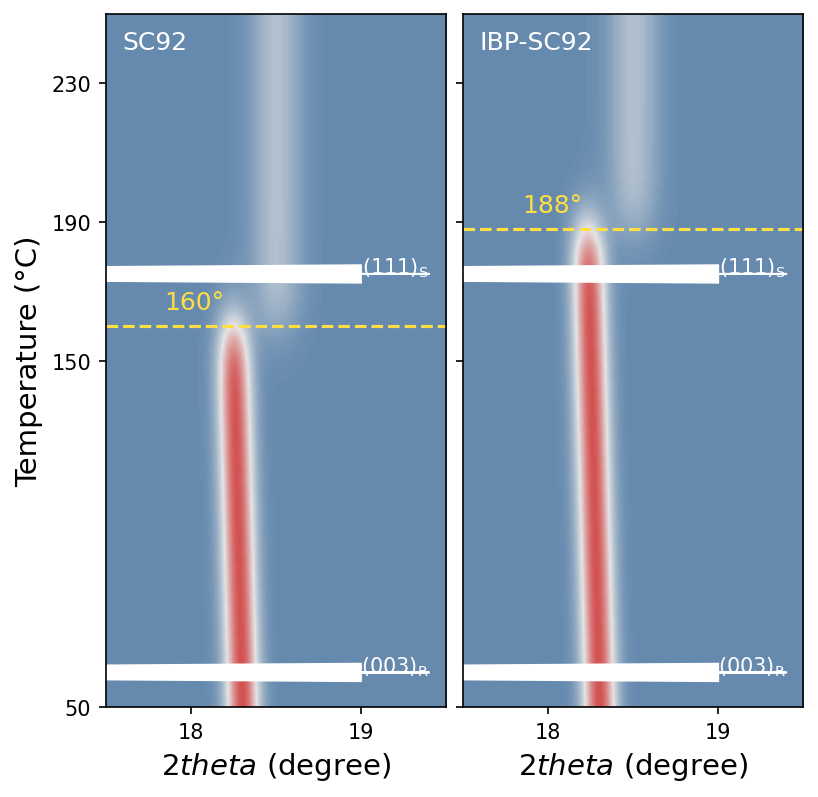

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- Data Simulation ---
# Y: Temperature (50 to 250)
temp = np.linspace(50, 250, 200)
# X: 2 Theta (17.5 to 19.5)
two_theta = np.linspace(17.5, 19.5, 200)
TT, T = np.meshgrid(two_theta, temp)

def peak_evolution(tt, t, transition_temp, start_pos, end_pos):
    # Peak is at start_pos for t < transition
    # Disappears or moves? Image shows peak ending.
    # Actually, one peak disappears and another appears at higher angle?
    # No, looks like a shift + fading.
    # Or simply:
    # Low T: Strong peak at ~18.3
    # High T: Weak/No peak
    # Transition is sharp
    
    # 1. Main Peak (003)R
    # Position shifts slightly left with T?
    pos = start_pos - 0.0005 * (t - 50)
    width = 0.1
    # Intensity kills at transition
    intensity = 1.0 / (1 + np.exp((t - transition_temp)/5))
    
    peak1 = intensity * np.exp(-((tt - pos)/width)**2)
    
    # 2. New Peak (111)S?
    # Appears at higher angle?
    # Image: (111)S points to the fading tip? Or is it the new phase?
    # Usually Spinel forms from Layered.
    # Let's simulate a slight new feature appearing
    pos2 = end_pos
    intensity2 = 1.0 / (1 + np.exp(-(t - transition_temp)/5))
    peak2 = 0.3 * intensity2 * np.exp(-((tt - pos2)/0.15)**2) # Broader, weaker
    
    return peak1 + peak2

# SC92 (Left) - Transition ~160
Z_sc92 = peak_evolution(TT, T, 160, 18.3, 18.5)

# IBP-SC92 (Right) - Transition ~188
Z_ibp = peak_evolution(TT, T, 188, 18.3, 18.5)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 6), dpi=150, sharey=True)
plt.subplots_adjust(wspace=0.05)

# Colormap: Blue to Red (White/Red for intensity)
# Custom: Blue background, White/Red peak
# Actually image has blue background, red peak.
colors = [(0.2, 0.4, 0.6), (0.9, 0.9, 0.9), (0.8, 0.1, 0.1)] # DarkBlue -> White -> Red
cmap = LinearSegmentedColormap.from_list('custom', colors, N=100)


# SC92
ax1.imshow(Z_sc92, aspect='auto', extent=[17.5, 19.5, 50, 250], cmap=cmap, vmin=-0.2, vmax=1.2, origin='lower')
ax1.text(0.05, 0.95, 'SC92', transform=ax1.transAxes, color='white', fontsize=12)
ax1.axhline(160, color='#FFDD44', linestyle='--')
ax1.text(18.2, 165, '160°', color='#FFDD44', ha='right', fontsize=12)

# IBP-SC92
ax2.imshow(Z_ibp, aspect='auto', extent=[17.5, 19.5, 50, 250], cmap=cmap, vmin=-0.2, vmax=1.2, origin='lower')
ax2.text(0.05, 0.95, 'IBP-SC92', transform=ax2.transAxes, color='white', fontsize=12)
ax2.axhline(188, color='#FFDD44', linestyle='--')
ax2.text(18.2, 193, '188°', color='#FFDD44', ha='right', fontsize=12)

# Labels
ax1.set_ylabel('Temperature (°C)', fontsize=14)
for ax in [ax1, ax2]:
    ax.set_xticks([18, 19])
    ax.set_xlim(17.5, 19.5)
    ax.set_xlabel(r'2$theta$ (degree)', fontsize=14)
    # Peak labels
    ax.text(19.4, 60, r'(003)$_{\mathrm{R}}$', color='white', ha='right')
    ax.arrow(19.4, 60, -0.4, 0, color='white', head_width=5)
    
    ax.text(19.4, 175, r'(111)$_{\mathrm{S}}$', color='white', ha='right')
    ax.arrow(19.4, 175, -0.4, 0, color='white', head_width=5)

ax1.set_yticks([50, 150, 190, 230])

plt.show()
